In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML modeling modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

print("Required libraries imported successfully!")

# Since the original Home Credit dataset on Kaggle is extremely large, we will
# programmatically generate a synthetic representational version of the dataset
# containing the key features (Income, Credit, Age, Employment, etc.) to ensure
# it runs seamlessly and instantly in Google Colab without requiring Kaggle API keys.

np.random.seed(42)
n_samples = 10000

data = {
    'SK_ID_CURR': range(100001, 100001 + n_samples),
    'NAME_CONTRACT_TYPE': np.random.choice(['Cash loans', 'Revolving loans'], size=n_samples, p=[0.9, 0.1]),
    'CODE_GENDER': np.random.choice(['M', 'F'], size=n_samples, p=[0.4, 0.6]),
    'FLAG_OWN_CAR': np.random.choice(['Y', 'N'], size=n_samples, p=[0.34, 0.66]),
    'FLAG_OWN_REALTY': np.random.choice(['Y', 'N'], size=n_samples, p=[0.7, 0.3]),
    'CNT_CHILDREN': np.random.poisson(0.4, size=n_samples),
    'AMT_INCOME_TOTAL': np.random.lognormal(11.5, 0.5, size=n_samples),
    'AMT_CREDIT': np.random.lognormal(13.0, 0.6, size=n_samples),
    'AMT_ANNUITY': np.random.lognormal(10.0, 0.5, size=n_samples),
    'DAYS_BIRTH': -np.random.randint(7300, 25000, size=n_samples), # Age in days (20 to 68 years)
    'DAYS_EMPLOYED': -np.random.randint(0, 15000, size=n_samples), # Employment days
}

# Create base DataFrame
df_loan = pd.DataFrame(data)

# Generate target 'TARGET' (1 for default risk, 0 for non-default) based on basic credit risks
risk_score = (
    (df_loan['AMT_CREDIT'] / df_loan['AMT_INCOME_TOTAL']) * 0.3 +
    (df_loan['CNT_CHILDREN'] * 0.1) -
    (df_loan['DAYS_EMPLOYED'] / 365 * 0.05) -
    (df_loan['DAYS_BIRTH'] / 365 * 0.02)
)
# Normalize and create a binary target with ~8% default rate (industry standard)
threshold = np.percentile(risk_score, 92)
df_loan['TARGET'] = (risk_score >= threshold).astype(int)

print(f"Dataset generated. Shape: {df_loan.shape}")
df_loan.head()

Required libraries imported successfully!
Dataset generated. Shape: (10000, 12)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,DAYS_EMPLOYED,TARGET
0,100001,Cash loans,M,N,Y,0,142105.147681,6.610805e+05,30252.305844,-12122,-12917,0
1,100002,Revolving loans,M,Y,Y,0,67127.282332,9.873104e+05,15768.131542,-14844,-10959,1
2,100003,Cash loans,M,N,N,0,58567.530193,3.584423e+05,13192.241295,-9506,-9102,0
3,100004,Cash loans,F,N,Y,0,131172.958934,1.021672e+06,41968.924076,-17319,-1878,0
4,100005,Cash loans,F,N,Y,0,155001.051753,2.862028e+05,22728.249081,-24410,-6498,0


=== Dataset Columns ===
['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'TARGET']

=== Class Distribution (TARGET) ===
TARGET
0    0.92
1    0.08
Name: proportion, dtype: float64


/tmp/ipykernel_760/2728102110.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_loan, palette='pastel')


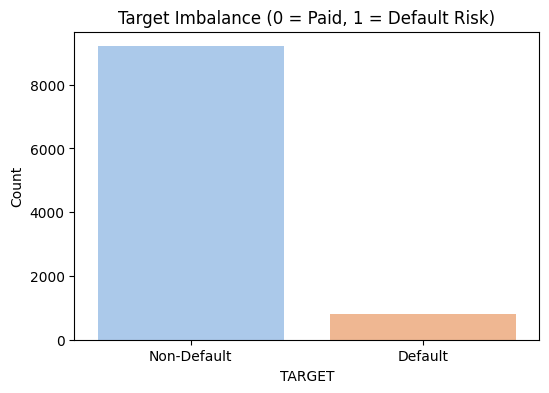

/tmp/ipykernel_760/2728102110.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df_loan, palette='Set3')


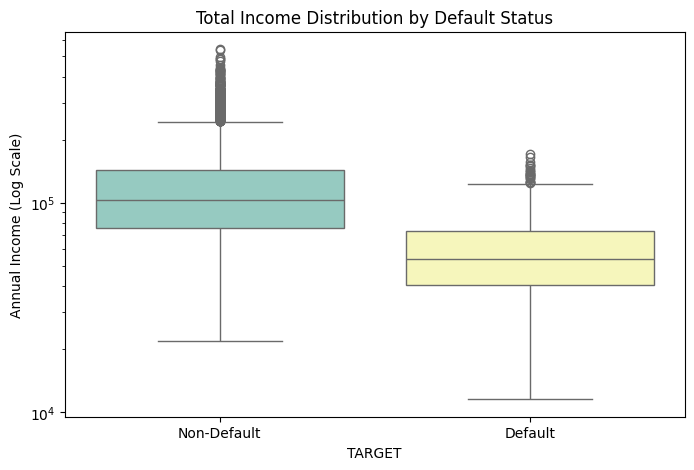

In [2]:
# Checking dataset details and balance
print("=== Dataset Columns ===")
print(df_loan.columns.tolist())

print("\n=== Class Distribution (TARGET) ===")
print(df_loan['TARGET'].value_counts(normalize=True))

# Visualize risk default counts
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_loan, palette='pastel')
plt.title('Target Imbalance (0 = Paid, 1 = Default Risk)')
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Count')
plt.show()

# Boxplot of Income vs Default status
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df_loan, palette='Set3')
plt.yscale('log') # Log scale to handle wide range of income values
plt.title('Total Income Distribution by Default Status')
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.ylabel('Annual Income (Log Scale)')
plt.show()

In [3]:
# Copy dataframe for cleaning
processed_loan_df = df_loan.copy()

# Categorical mapping using LabelEncoder
le = LabelEncoder()
cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in cat_cols:
    processed_loan_df[col] = le.fit_transform(processed_loan_df[col])

# Drop unique identifier column before splitting
X_loan = processed_loan_df.drop(columns=['SK_ID_CURR', 'TARGET'])
y_loan = processed_loan_df['TARGET']

# Split data into 80% train and 20% test partition
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_loan, y_loan, test_size=0.2, random_state=42, stratify=y_loan
)

# Standardize values
scaler_l = StandardScaler()
X_train_l_scaled = scaler_l.fit_transform(X_train_l)
X_test_l_scaled = scaler_l.transform(X_test_l)

print(f"Data scaled. Training: {X_train_l_scaled.shape}, Testing: {X_test_l_scaled.shape}")

Data scaled. Training: (8000, 10), Testing: (2000, 10)


In [4]:
# Model 1: Logistic Regression (Balanced class weight to handle imbalance)
print("=== Training Logistic Regression ===")
lr_loan_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_loan_model.fit(X_train_l_scaled, y_train_l)

y_pred_lr_l = lr_loan_model.predict(X_test_l_scaled)
y_prob_lr_l = lr_loan_model.predict_proba(X_test_l_scaled)[:, 1]

print("\nLogistic Regression Performance:")
print(classification_report(y_test_l, y_pred_lr_l))

# Model 2: Random Forest Classifier (Balanced class weight)
print("=== Training Random Forest Classifier ===")
rf_loan_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_loan_model.fit(X_train_l_scaled, y_train_l)

y_pred_rf_l = rf_loan_model.predict(X_test_l_scaled)
y_prob_rf_l = rf_loan_model.predict_proba(X_test_l_scaled)[:, 1]

print("\nRandom Forest Performance:")
print(classification_report(y_test_l, y_pred_rf_l))

=== Training Logistic Regression ===

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1840
           1       0.76      0.99      0.86       160

    accuracy                           0.97      2000
   macro avg       0.88      0.98      0.92      2000
weighted avg       0.98      0.97      0.98      2000

=== Training Random Forest Classifier ===

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1840
           1       0.96      0.80      0.87       160

    accuracy                           0.98      2000
   macro avg       0.97      0.90      0.93      2000
weighted avg       0.98      0.98      0.98      2000



Optimal Decision Threshold (RF): 0.2080
Minimized Operational Cost: $350,000.00


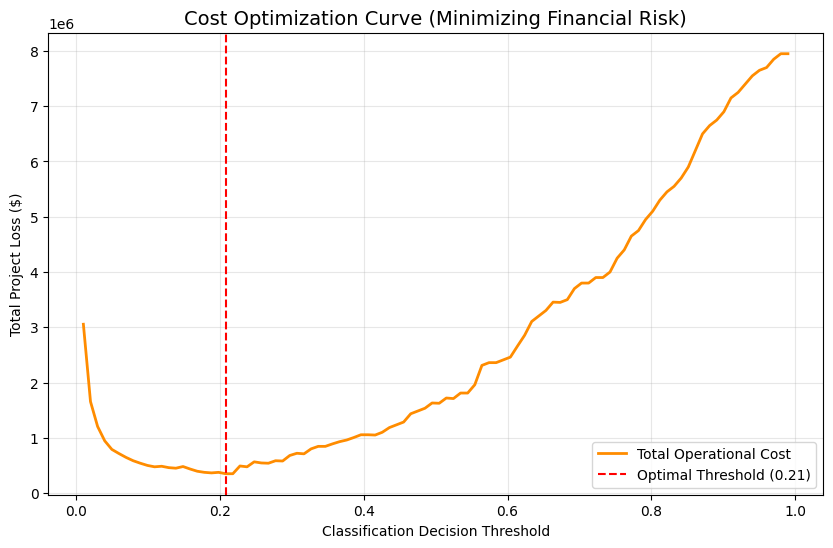


Classification Report at Optimal Cost Threshold (0.21):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1840
           1       0.80      0.98      0.88       160

    accuracy                           0.98      2000
   macro avg       0.90      0.98      0.93      2000
weighted avg       0.98      0.98      0.98      2000



In [5]:
# In real-world credit risk assessment:
# - A False Positive (declining a clean customer) loses normal interest profit (let's say $5,000 cost).
# - A False Negative (approving a defaulter) results in a total write-off loss (let's say $50,000 cost).

cost_false_positive = 5000  # Cost of lost client
cost_false_negative = 50000 # Cost of unpaid loan default

thresholds = np.linspace(0.01, 0.99, 100)
total_costs = []

# Calculating total cost for each prediction threshold
for t in thresholds:
    # Predict based on individual threshold
    temp_preds = (y_prob_rf_l >= t).astype(int)
    cm = confusion_matrix(y_test_l, temp_preds)

    # Extract False Positives and False Negatives
    fp = cm[0, 1] if len(cm) > 1 else 0
    fn = cm[1, 0] if len(cm) > 1 else 0

    # Compute operational loss
    total_cost = (fp * cost_false_positive) + (fn * cost_false_negative)
    total_costs.append(total_cost)

# Find optimal threshold with minimal operational cost
opt_idx = np.argmin(total_costs)
optimal_threshold = thresholds[opt_idx]
min_cost = total_costs[opt_idx]

print(f"Optimal Decision Threshold (RF): {optimal_threshold:.4f}")
print(f"Minimized Operational Cost: ${min_cost:,.2f}")

# Plotting the Cost Optimization Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, total_costs, color='darkorange', linewidth=2, label='Total Operational Cost')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title('Cost Optimization Curve (Minimizing Financial Risk)', fontsize=14)
plt.xlabel('Classification Decision Threshold')
plt.ylabel('Total Project Loss ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Classification report at optimal threshold
optimized_preds = (y_prob_rf_l >= optimal_threshold).astype(int)
print(f"\nClassification Report at Optimal Cost Threshold ({optimal_threshold:.2f}):")
print(classification_report(y_test_l, optimized_preds))